<a href="https://colab.research.google.com/github/nshekek-source/Movie-Trend-Analytics/blob/main/Movie_Trend_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle -q

# Download MovieLens dataset directly
!wget -q https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip -q ml-latest-small.zip
print("Dataset downloaded!")


Dataset downloaded!


In [2]:
import pandas as pd

movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
movies.head()

Movies: (9742, 3)
Ratings: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


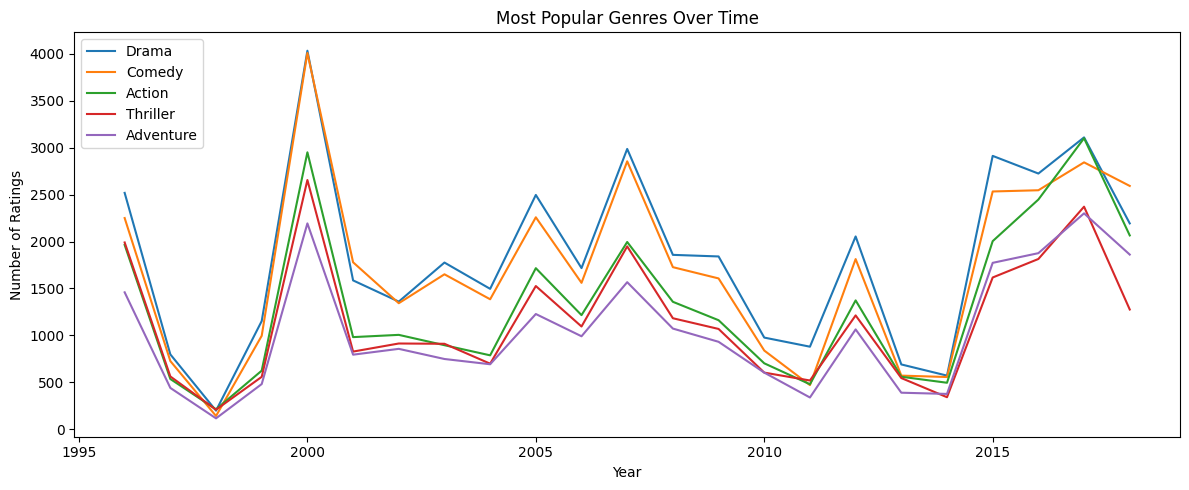

In [3]:
import matplotlib.pyplot as plt

ratings['year'] = pd.to_datetime(ratings['timestamp'], unit='s').dt.year
merged = ratings.merge(movies, on='movieId')
merged['genres'] = merged['genres'].str.split('|')
exploded = merged.explode('genres')

genre_trend = exploded.groupby(['year','genres']).size().reset_index(name='count')
top_genres = exploded['genres'].value_counts().head(5).index

plt.figure(figsize=(12,5))
for genre in top_genres:
    data = genre_trend[genre_trend['genres'] == genre]
    plt.plot(data['year'], data['count'], label=genre)

plt.title('Most Popular Genres Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Ratings')
plt.legend()
plt.tight_layout()
plt.savefig('output_genres.png')
plt.show()

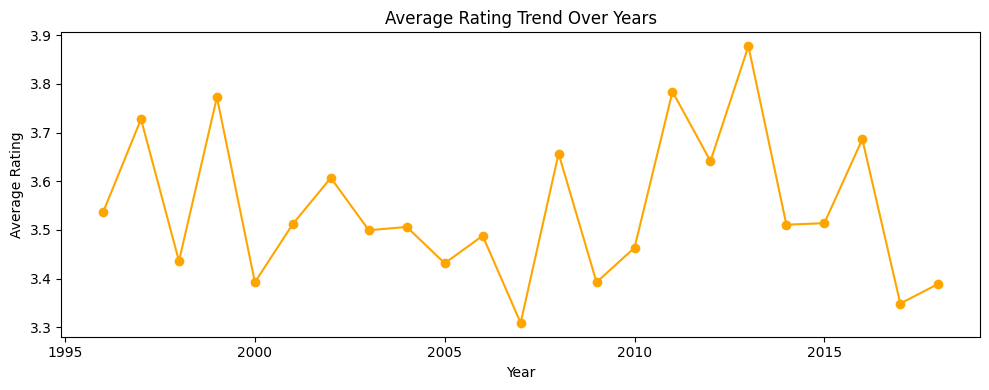

In [4]:
rating_trend = merged.groupby('year')['rating'].mean().reset_index()

plt.figure(figsize=(10,4))
plt.plot(rating_trend['year'], rating_trend['rating'], marker='o', color='orange')
plt.title('Average Rating Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.savefig('output_ratings.png')
plt.show()


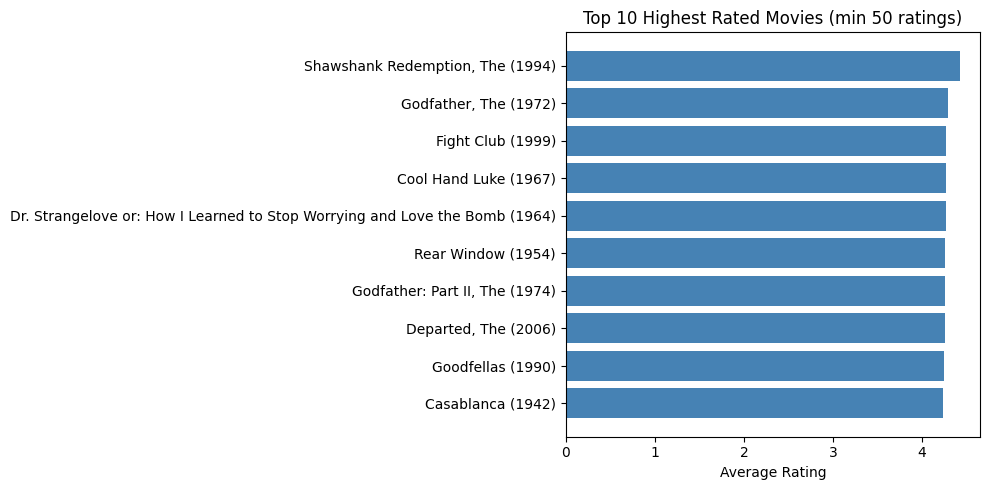

In [7]:
# Fix: use original merged df (genres as string, not list)
movie_avg = ratings.merge(movies, on='movieId')
movie_avg_grouped = movie_avg.groupby('title')['rating'].agg(['mean','count']).reset_index()
movie_avg_grouped = movie_avg_grouped[movie_avg_grouped['count'] >= 50].sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(movie_avg_grouped['title'], movie_avg_grouped['mean'], color='steelblue')
plt.title('Top 10 Highest Rated Movies (min 50 ratings)')
plt.xlabel('Average Rating')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('output_top_movies.png')
plt.show()